In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("netflix.csv")

In [3]:
df.head()
# to show first 5 rows of dataset

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.info()
# provides structure and data type of dataset.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.isnull().sum()
# idntifies missing values in dataset

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
df.describe()
# gives statistical summary of numerical data such as count,mean,max etc.

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
genres = df['listed_in'].str.split(',').explode()

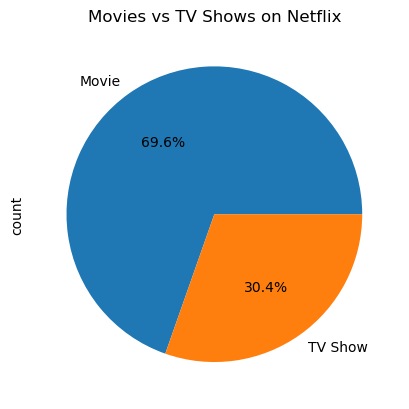

In [10]:
#A). Content Strategy

#1. What is the ratio of Movies vs TV Shows on Netflix?

df['type'].value_counts()
df['type'].value_counts(normalize=True)*100
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Movies vs TV Shows on Netflix")
plt.show()

In [ ]:
#INSIGHTS
A. A large movie library helps Netflix quickly expand content variety all over.
B. Movies are cheaper and faster to produce compared to different season of the TV shows.
C. Two-third of the Netflix content consist of Movies and left of that one-third is TV Shows.

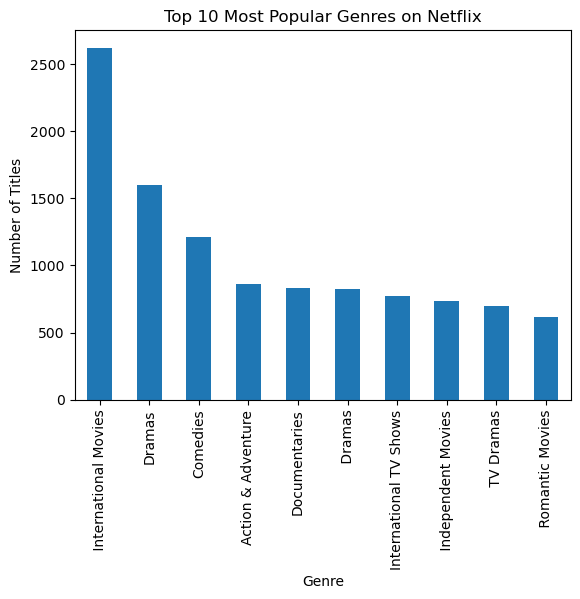

In [15]:
#2.Which genres are most popular on Netflix globally?

genres.value_counts().head(10)
genres.value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Most Popular Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.show()

In [ ]:
#INSIGHTS
A. International movies are very popular on the Netflix.
B. Netflix should continue investing in Drama and Comedy,as these genres attract the large no of audiences.
C. Making more International Movies can help Netflix grow in different- different countries.

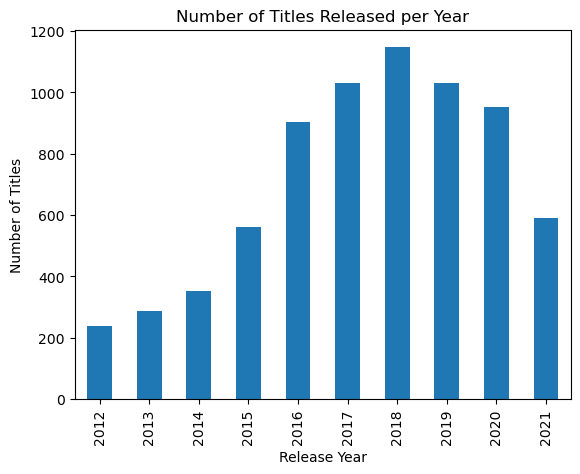

In [20]:
#3.Which years saw the highest release of content on Netflix?

df['release_year'].value_counts().head(10)
df['release_year'].value_counts().head(10).sort_index().plot(kind='bar')
plt.title("Number of Titles Released per Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

In [ ]:
#INSIGHTS
A. Netflix aggressively increased content production IN YEAR 2016–2020 to attract more subscribers OR viewers worldwide.
B. Large content library helps Netflix retain viewers and competition  with other streaming platforms.
C. The highest no of Netflix content were released around 2018–2019,shows when Netflix aggressively expanded its content
library & invested heavily in new productions.

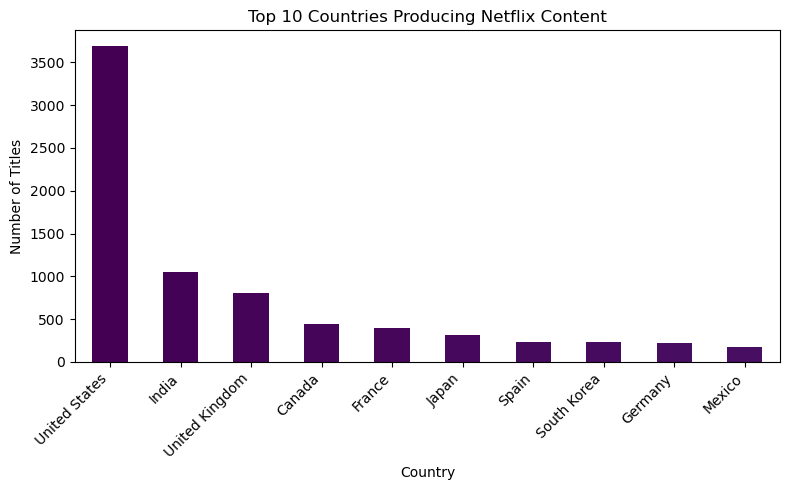

In [47]:
#4. Which countries produce the most Netflix content?

import matplotlib.pyplot as plt

countries = df['country'].str.split(',').explode().str.strip()

top_countries = countries.value_counts().head(10)

plt.figure(figsize=(8,5))

top_countries.plot(kind='bar', color=plt.cm.viridis(range(10)))

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
#INSIGHTS
A. India is one of the fastest-growing content producers on Netflix.
B. Growing production in India which means (Asia indicates Netflix’s strategy to expand in  markets.

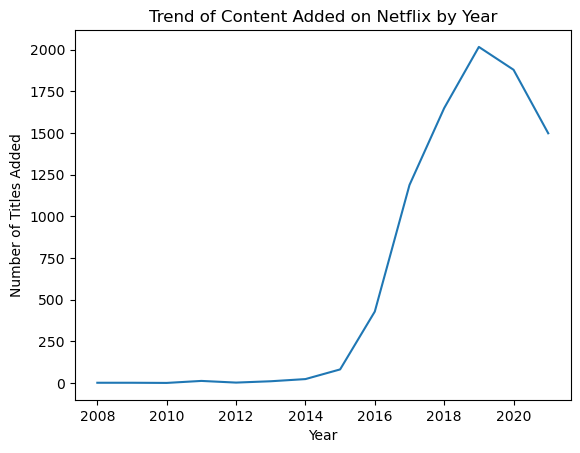

In [23]:
#5. How has the trend of adding new content evolved year by year?

# Convert to datetime
df['date_added'] = pd.to_datetime(df['date_added'])
# Extract year
df['year_added'] = df['date_added'].dt.year
df['year_added'].value_counts().sort_index()
df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Trend of Content Added on Netflix by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.show()

In [ ]:
#INSIGHTS
A. A large amount of content added on Netflix in year between 2016 & 2018.
B. After 2020 the growth became more stable, showing a controlled content strategy.

In [24]:
#B). User Demographics & Targeting...

#6. Which ratings(e.g.,TV-MA,PG,etc.) are most frequent on Netflix?

df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [ ]:
#INSIGHTS
A. TV-MA appears the most on Netflix.
B. Netflix mostly launching the shows for the mature and teenage audience.

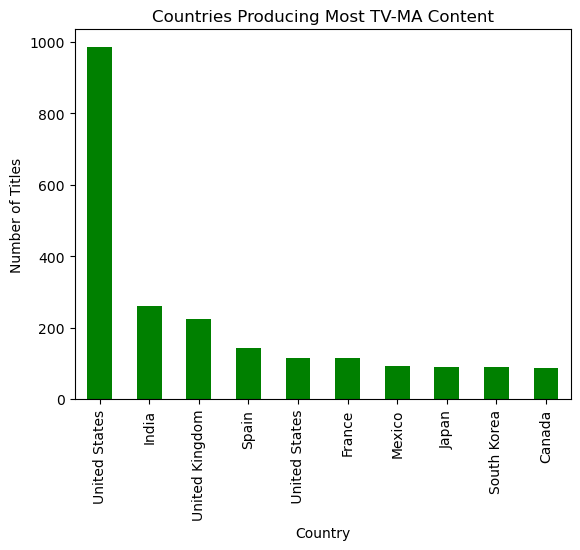

In [61]:
#7. Do some countries tend to produce more mature content (TV-MA)?

df[df['rating']=="TV-MA"]['country'].value_counts().head(10)
df_tvma = df[df['rating']=="TV-MA"]

countries = df_tvma['country'].str.split(',').explode()

countries.value_counts().head(10).plot(kind='bar' , color='green')

plt.title("Countries Producing Most TV-MA Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

In [ ]:
#INSIGHTS
A. United states produces the highest mature content.
B. Netflix can uses regional maturity preferences.

In [7]:
#8. Which genres are more associated with TV Shows vs Movies?

df.groupby('type')['listed_in'].value_counts().head(10)

type   listed_in                                       
Movie  Dramas, International Movies                        362
       Documentaries                                       359
       Stand-Up Comedy                                     334
       Comedies, Dramas, International Movies              274
       Dramas, Independent Movies, International Movies    252
       Children & Family Movies                            215
       Children & Family Movies, Comedies                  201
       Documentaries, International Movies                 186
       Dramas, International Movies, Romantic Movies       180
       Comedies, International Movies                      176
Name: count, dtype: int64

In [ ]:
#INSIGHTS
A. Tv shows focuses more on the dramas and more intresting stories.
B. Tv shows-long term engagement of the viewers for their entertainment purpose.
C. Movies-quick entertainment.

In [8]:
#9. Which genres dominate the U.S. vs other countries?

us = df[df['country'].str.contains("United States", na=False)]

us['listed_in'].str.split(',').explode().value_counts().head(10)

non_us = df[~df['country'].str.contains("United States", na=False)]

non_us['listed_in'].str.split(',').explode().value_counts().head(10)

listed_in
 International Movies      2463
Dramas                     1053
Comedies                    804
International TV Shows      744
 Dramas                     539
 International TV Shows     533
 TV Dramas                  526
Action & Adventure          455
 Romantic Movies            390
 Independent Movies         361
Name: count, dtype: int64

In [ ]:
#INSIGHTS
A. The U.S produces mainstream entertainment genres.
B. Other countries focus more on regional and international storytelling.
C. Netflix should provide geo-targeted recommendations based on regional genre preferences.

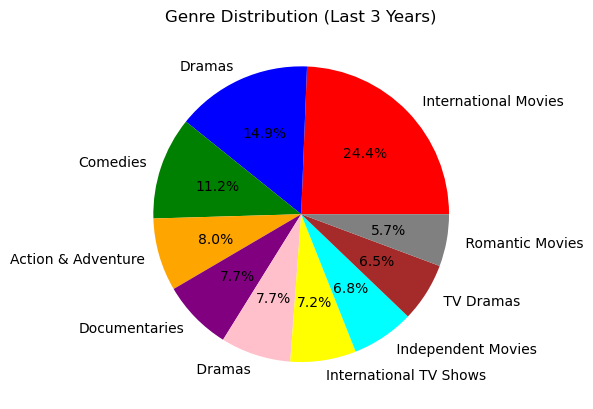

In [10]:
#10. What genres are most popular in the last 3 years?

genres.value_counts().head(10).plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['red','blue','green','orange','purple','pink','yellow','cyan','brown','grey'])
plt.title("Genre Distribution (Last 3 Years)")
plt.ylabel("")
plt.show()

In [ ]:
#INSIGHTS
A. Netflix should invest more in: Crime series & Documentaries.
B. Drama remains consistently popular.

In [11]:
#C).  Talent Acquisition & Partnerships...

#11. Who are the top 10 directors with the most Netflix content?

df['director'].value_counts().head(10)

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64

In [ ]:
#INSIGHTS
A. Netflix can partner more with these directors to ensure successful content.
B. Some directors frequently collaborate with Netflix.
C. These directors are key content creators.

In [12]:
#12. Which actors appear most frequently in Netflix shows?

actors = df['cast'].str.split(',').explode().str.strip()

actors.value_counts().head(10)

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Paresh Rawal        28
Name: count, dtype: int64

In [ ]:
#INSIGHTS
A. These actors help attract audience attentiont.
B. Netflix can retain popular actors for better engagement.

In [13]:
#13. Which director-genre pairs are most frequent?

df['genre'] = df['listed_in'].str.split(',').str[0].str.strip()
df.groupby(['director','genre']).size().sort_values(ascending=False).head(10)

director                genre                   
Rajiv Chilaka           Children & Family Movies    19
Raúl Campos, Jan Suter  Stand-Up Comedy             18
Suhas Kadav             Children & Family Movies    16
Marcus Raboy            Stand-Up Comedy             15
Jay Karas               Stand-Up Comedy             13
Jay Chapman             Stand-Up Comedy             11
Don Michael Paul        Action & Adventure           9
Shannon Hartman         Stand-Up Comedy              8
Hakan Algül             Comedies                     8
Youssef Chahine         Classic Movies               7
dtype: int64

In [ ]:
#INSIGHTS
A. Some directors specialize in specific genres.
B. Netflix can assign directors to genres where they perform best.

In [14]:
#14. How many titles have unknown directors or cast members?

df['director'].isnull().sum()
df['cast'].isnull().sum()

np.int64(825)

In [ ]:
#INSIGHTS
A. Some titles lack director or cast information.
B. Improve metadata quality.

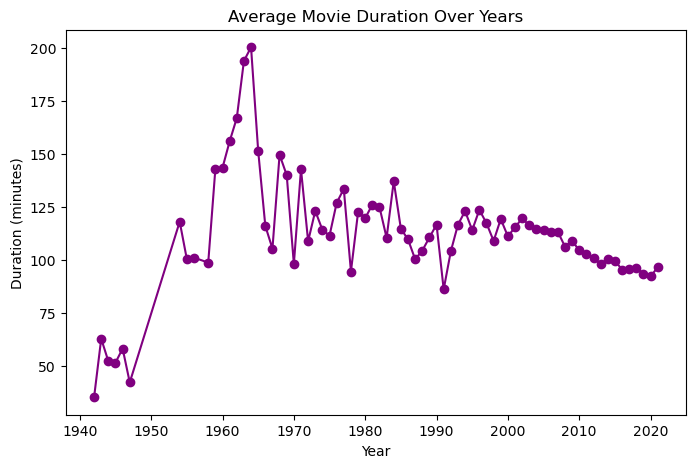

In [23]:
#D). Duration & Engagement...

#15. What is the average duration of Movies on Netflix?

movies = df[df['type']=="Movie"].copy()

movies['duration'] = movies['duration'].str.replace(" min","").astype(float)

plt.figure(figsize=(8,5))

movies.groupby('release_year')['duration'].mean().plot(
    kind='line',
    marker='o',
    color='purple'
)

plt.title("Average Movie Duration Over Years")
plt.xlabel("Year")
plt.ylabel("Duration (minutes)")

plt.show()

In [ ]:
#INSIGHTS
A. Most movies follow a standard duration format.
B. Netflix can maintain optimal movie length for engagement.

In [16]:
#16. What’s the most common number of seasons for TV shows?

tv = df[df['type']=="TV Show"]

tv['duration'].value_counts().head(10)

duration
1 Season      1793
2 Seasons      425
3 Seasons      199
4 Seasons       95
5 Seasons       65
6 Seasons       33
7 Seasons       23
8 Seasons       17
9 Seasons        9
10 Seasons       7
Name: count, dtype: int64

In [ ]:
#INSIGHTS
A. Most shows have 1–2 seasons.
B. Few shows go beyond 5 seasons.
C. Netflix prefers short series → faster production + higher retention.

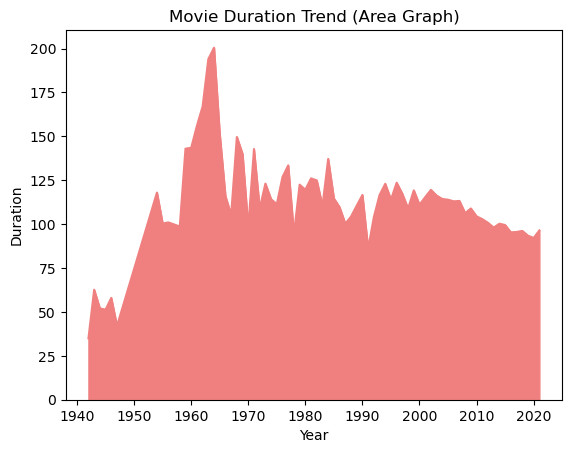

In [25]:
#17. Is there a trend in movie durations over the years?

movies.groupby('release_year')['duration'].mean().plot(
    kind='area',
    color='lightcoral'
)

plt.title("Movie Duration Trend (Area Graph)")
plt.xlabel("Year")
plt.ylabel("Duration")

plt.show()

In [ ]:
#INSIGHTS
A. Movie duration is mostly stable over time.
B. Slight variation depending on trends.

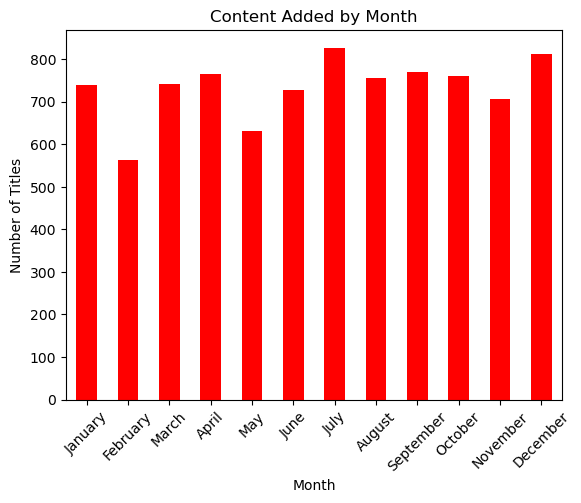

In [29]:
#E). Content Launch Strategy...

#18. In which months does Netflix add the most content?

df['date_added'] = pd.to_datetime(df['date_added'])

df['month_name'] = df['date_added'].dt.month_name()
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

month_counts = df['month_name'].value_counts().reindex(month_order)

month_counts.plot(kind='bar', color='red')

plt.title("Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

In [ ]:
#INSIGHTS
A. Netflix should release major content during holiday seasons for higher viewership.
B. Most content is added in July and December.

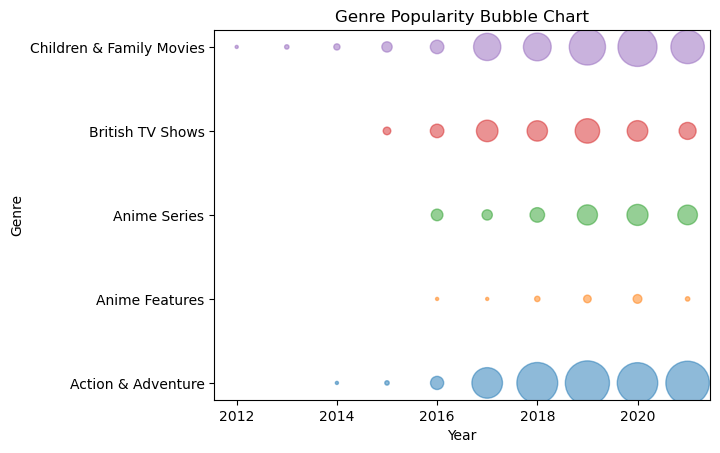

In [40]:
#19. How does the genre distribution vary across different years?

data = genre_year.tail(10)

for genre in data.columns[:5]:   # top 5 genres
    plt.scatter(data.index, [genre]*len(data.index),
                s=data[genre]*5, alpha=0.5)

plt.title("Genre Popularity Bubble Chart")
plt.xlabel("Year")
plt.ylabel("Genre")

plt.show()

In [ ]:
#INSIGHTS
A. International content has increased significantly.
B. Netflix content is becoming more diverse.

In [30]:
#20. Which countries produce the most content in each genre?

df['genre'] = df['listed_in'].str.split(',').str[0].str.strip()

df.groupby(['country','genre']).size().sort_values(ascending=False).head(10)

country         genre                   
United States   Documentaries               388
India           Dramas                      384
United States   Dramas                      376
                Comedies                    338
India           Comedies                    262
United States   Children & Family Movies    256
                Action & Adventure          249
                Stand-Up Comedy             209
United Kingdom  British TV Shows            196
United States   Kids' TV                    142
dtype: int64

In [ ]:
#INSIGHTS
A. USA dominates multiple genres like Drama, Comedy & Action.
B. India contributes heavily to Drama and Romance.